<a href="https://colab.research.google.com/github/kowshika-santhosh-2111data/Driver_Drowsiness_Detection/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
import random
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"

classes = ["Open", "Closed", "yawn", "no_yawn"]

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"))

['yawn', 'Open', 'no_yawn', 'Closed']


In [ ]:
images = []
labels = []

for label, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))

        images.append(img)
        labels.append(label)

x = np.array(images, dtype=np.float32)
y = np.array(labels)


In [ ]:
x = x / 255.0

In [ ]:
# Convert to NumPy array
y = np.array(y)

# One-hot encode labels
y = to_categorical(y, num_classes=4)

print(y[:5])

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [ ]:
x_train_cnn, x_test_cnn, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

In [ ]:
labels = np.argmax(y_train, axis=1)

for i, c in enumerate(np.bincount(labels)):
    print(f"{classes[i]} : {c}")

Open : 581
Closed : 581
yawn : 578
no_yawn : 580


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
train_generator = datagen.flow(
    x_train_cnn,
    y_train,
    batch_size=32
)

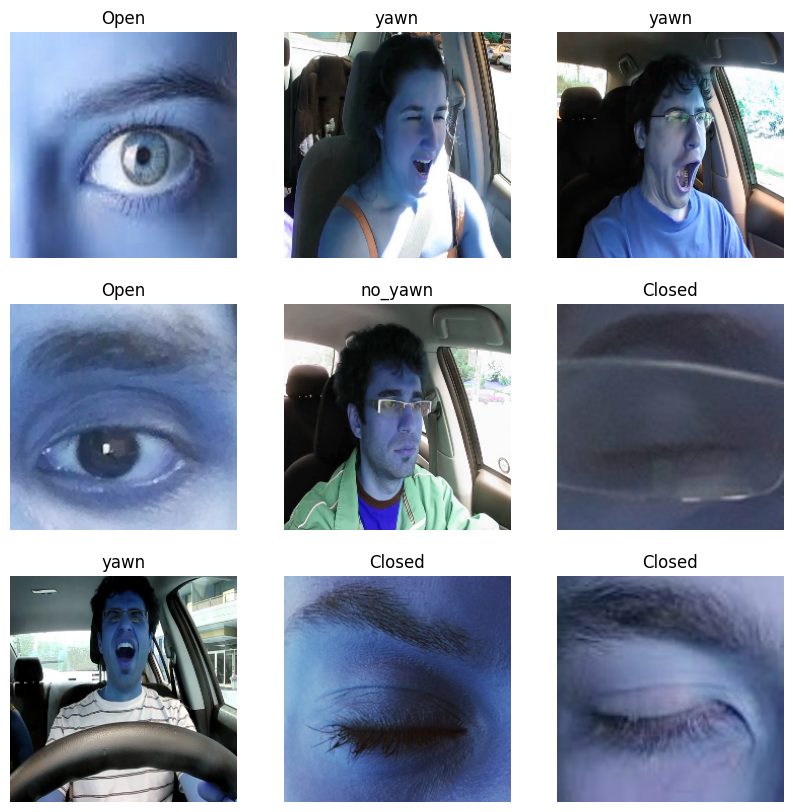

In [ ]:
plt.figure(figsize=(10,10))

for i in range(9):
    idx = np.random.randint(len(x_train_cnn))
    plt.subplot(3,3,i+1)
    plt.imshow(x_train_cnn[idx])
    plt.title(classes[np.argmax(y_train[idx])])
    plt.axis("off")

plt.show()

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(4, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 111, 111, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 55, 55, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,540 (1.87 MB)

 Trainable params: 488,580 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Driver_Drowsiness_Detection/cnn_driver_drowsiness.keras",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9982788296041308), 1: np.float64(0.9982788296041308), 2: np.float64(1.0034602076124568), 3: np.float64(1.0)}


In [ ]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=(x_test_cnn, y_test),
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 59s 619ms/step - accuracy: 0.3306 - loss: 1.4544 - val_accuracy: 0.4397 - val_loss: 1.3731 - learning_rate: 1.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 448ms/step - accuracy: 0.3651 - loss: 1.3053 - val_accuracy: 0.3052 - val_loss: 1.3615 - learning_rate: 1.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 464ms/step - accuracy: 0.3638 - loss: 1.2765 - val_accuracy: 0.2552 - val_loss: 1.3594 - learning_rate: 1.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 453ms/step - accuracy: 0.3754 - loss: 1.2581 - val_accuracy: 0.2500 - val_loss: 1.4965 - learning_rate: 1.0000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 446ms/step - accuracy: 0.3754 - loss: 1.2493 - val_accuracy: 0.2500 - val_loss: 2.4063 - learning_rate: 1.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 460ms/step - accuracy: 0.3784 - loss: 1.2666 - val_accuracy: 0.2500 - val_loss: 3.2181 - learning_rate: 1.0000e-04
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 444ms/step - acc

In [ ]:
cnn_model.save(
"/content/drive/MyDrive/Driver_Drowsiness_Detection/cnn_driver_drowsiness.keras"
)

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 111, 111, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 55, 55, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,702 (5.60 MB)

 Trainable params: 488,580 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 977,162 (3.73 MB)

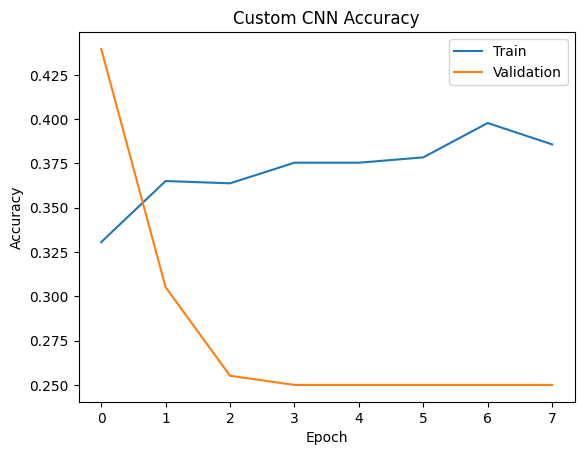

In [ ]:
# Accuracy
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

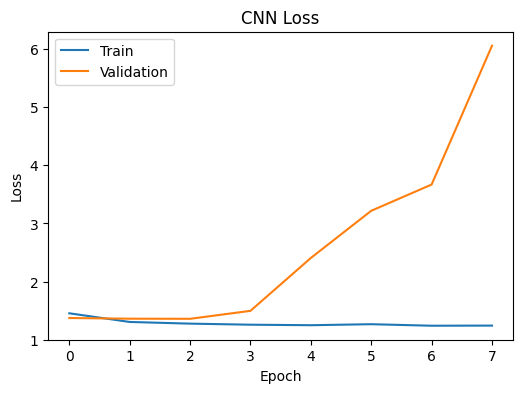

In [ ]:
# Loss
plt.figure(figsize=(6,4))
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
y_pred = cnn_model.predict(x_test_cnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


In [ ]:
y_pred_labels = np.argmax(y_pred,axis=1)

if len(y_test.shape)==2:
    y_test_labels = np.argmax(y_test,axis=1)
else:
    y_test_labels = y_test

In [ ]:
# Check class prediction distribution
print("Prediction Distribution:")
unique, counts = np.unique(y_pred_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{classes[u]} : {c}")

Prediction Distribution:
Open : 6
Closed : 2
no_yawn : 572


In [ ]:
cm = confusion_matrix(
    y_test_labels,
    y_pred_labels
)

In [ ]:
print(classification_report(
    y_test_labels,
    y_pred_labels,
    target_names=['Open','Closed','Yawn','No_yawn']
))

              precision    recall  f1-score   support

        Open       0.50      0.02      0.04       145
      Closed       0.00      0.00      0.00       145
        Yawn       0.00      0.00      0.00       145
     No_yawn       0.25      1.00      0.40       145

    accuracy                           0.26       580
   macro avg       0.19      0.26      0.11       580
weighted avg       0.19      0.26      0.11       580



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


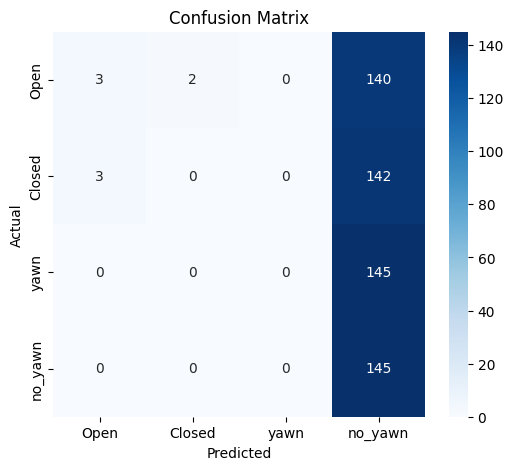

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

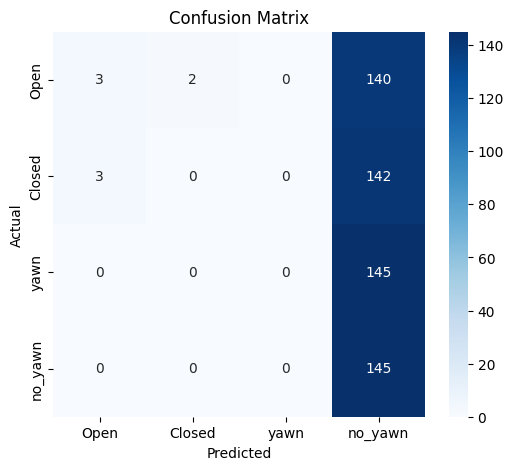

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

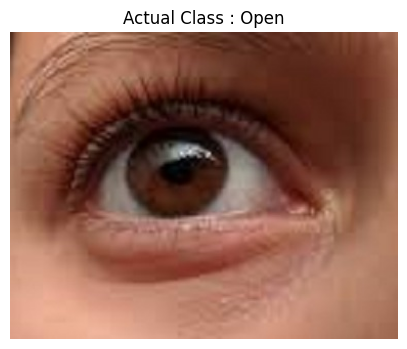

Actual Class    : Open
Predicted Class : no_yawn
Confidence      : 32.55%


In [ ]:
base_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"

selected_class = "Open"
image_name = "_100.jpg"

classes = ["Open", "Closed", "yawn", "no_yawn"]

img_path = os.path.join(base_path, selected_class, image_name)

img = cv2.imread(img_path)

if img is None:
    print("Image not found!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Actual Class : {selected_class}")
    plt.show()

    img_input = cv2.resize(img, (224,224))
    img_input = img_input.astype("float32") / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    prediction = cnn_model.predict(img_input, verbose=0)

    pred_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print("Actual Class    :", selected_class)
    print("Predicted Class :", classes[pred_class])
    print(f"Confidence      : {confidence:.2f}%")

In [ ]:
fatigue_levels=[]

for cls in y_pred_labels:

    if cls in [0,3]:
        fatigue_levels.append(0)

    elif cls==2:
        fatigue_levels.append(1)

    elif cls==1:
        fatigue_levels.append(2)

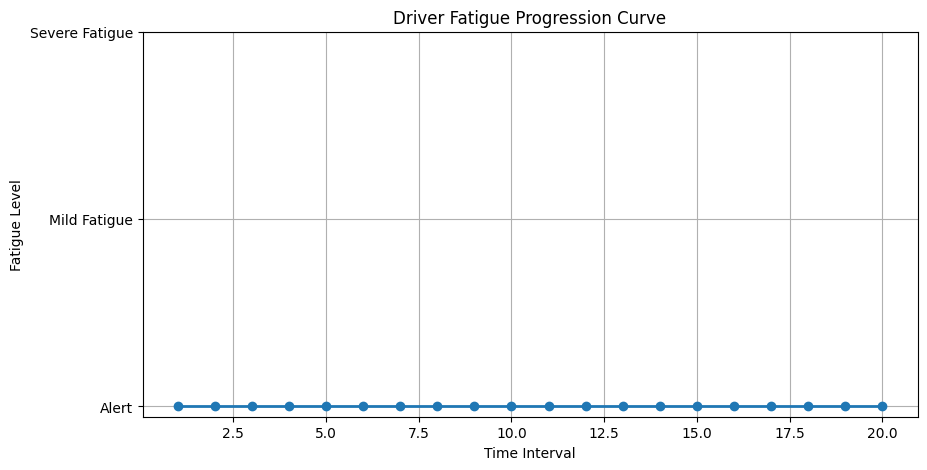

In [ ]:
frames_per_interval=30

progression=[]

for i in range(0,len(fatigue_levels),frames_per_interval):

    interval=fatigue_levels[i:i+frames_per_interval]

    dominant=np.bincount(interval).argmax()

    progression.append(dominant)

plt.figure(figsize=(10,5))

plt.plot(
    range(1,len(progression)+1),
    progression,
    marker='o',
    linewidth=2
)

plt.yticks(
    [0,1,2],
    ['Alert','Mild Fatigue','Severe Fatigue']
)

plt.xlabel("Time Interval")
plt.ylabel("Fatigue Level")
plt.title("Driver Fatigue Progression Curve")

plt.grid(True)

plt.show()

In [ ]:
# Convert one-hot encoded labels to class indices
y_test_labels = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='weighted')
recall = recall_score(y_test_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')

print("-" * 40)
print("Performance Analysis")
print("-" * 40)

print("Model Used      : Custom CNN")
print(f"Test Accuracy   : {accuracy:.2%}")
print(f"Accuracy        : {accuracy*100:.2f}%")
print(f"Precision       : {precision*100:.2f}%")
print(f"Recall          : {recall*100:.2f}%")
print(f"F1 Score        : {f1*100:.2f}%")

print("\nStrengths")
print("- Learns spatial image features automatically.")
print("- Detects eye closure and yawning patterns.")
print("- End-to-end deep learning approach.")

print("\nLimitations")
print("- Validation accuracy is lower than expected.")
print("- Model may require more data or tuning for higher accuracy.")
print("- Performance is lower than MobileNetV2.")

print("\nConclusion")
print("The Custom CNN serves as a baseline model. Although it successfully detects driver states, MobileNetV2 provides better accuracy and generalization.")

----------------------------------------
Performance Analysis
----------------------------------------
Model Used      : Custom CNN
Test Accuracy   : 25.52%
Accuracy        : 25.52%
Precision       : 18.84%
Recall          : 25.52%
F1 Score        : 11.10%

Strengths
- Learns spatial image features automatically.
- Detects eye closure and yawning patterns.
- End-to-end deep learning approach.

Limitations
- Validation accuracy is lower than expected.
- Model may require more data or tuning for higher accuracy.
- Performance is lower than MobileNetV2.

Conclusion
The Custom CNN serves as a baseline model. Although it successfully detects driver states, MobileNetV2 provides better accuracy and generalization.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
